24RB1074　半田悠人

## 課題1：データ生成（load_breast_cancer）

In [29]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"全体データ数: {X.shape}")
print(f"訓練データ数: {X_train.shape}")
print(f"テストデータ数: {X_test.shape}")
print(f"クラス名: {cancer.target_names}") 

全体データ数: (569, 30)
訓練データ数: (398, 30)
テストデータ数: (171, 30)
クラス名: ['malignant' 'benign']


### 課題2-1：LinearDiscriminantAnalysis（今回は手動実装）

In [30]:
import numpy as np
from sklearn.metrics import accuracy_score

class LDA:
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        self.classes_ = np.unique(y)

        pre_p = []
        means = [] 
        cov_matrices = np.zeros((n_features, n_features))

        for c in self.classes_:
            X_c = X[y == c]
            
            mean_c = np.mean(X_c, axis=0)
            means.append(mean_c)

            p_c = X_c.shape[0] / n_samples
            pre_p.append(p_c)

            X_c_centered = X_c - mean_c
            cov_matrices += X_c_centered.T @ X_c_centered

        cov_matrices /= n_samples
        cov_matrices_inv = np.linalg.inv(cov_matrices)

        self.w_ = cov_matrices_inv @ (means[1] - means[0])
        self.b_ = -0.5 * (means[1] + means[0]) @ self.w_ + np.log(pre_p[1] / pre_p[0])

    def predict(self, X):
        predictions = []

        for x in X:
            score = self.w_.T @ x + self.b_
            
            if score > 0:
                predictions.append(self.classes_[1])
            else:
                predictions.append(self.classes_[0])
                
        return np.array(predictions)
    
my_lda = LDA()
my_lda.fit(X_train, y_train)

y_pred = my_lda.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("--- LDA ---")
print(f"Accuracy: {accuracy:.4f}")

--- LDA ---
Accuracy: 0.9532


### 課題2-2：GaussianNB（sklearnよりインポート）

In [31]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. モデルの初期化
gnb = GaussianNB()

# 2. 学習
gnb.fit(X_train, y_train)

# 3. 予測
y_pred_gnb = gnb.predict(X_test)

# 4. 評価
acc_gnb = accuracy_score(y_test, y_pred_gnb)

print("--- Gaussian Naive Bayes ---")
print(f"Accuracy : {acc_gnb:.4f}")


--- Gaussian Naive Bayes ---
Accuracy : 0.9415


### 課題2-3：LogisticRegression（sklearnからインポート）

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. モデルの初期化
lr = LogisticRegression(max_iter=10000)

# 2. 学習
lr.fit(X_train, y_train)

# 3. 予測
y_pred_lr = lr.predict(X_test)

# 4. 評価
acc_lr = accuracy_score(y_test, y_pred_lr)

print("--- Logistic Regression ---")
print(f"Accuracy : {acc_lr:.4f}")


--- Logistic Regression ---
Accuracy : 0.9766


## 課題２：3手法の精度比較

In [33]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

models = {
    "My LDA (手動実装)": LDA(),
    "sklearn LDA": LinearDiscriminantAnalysis(),
    "GaussianNB": GaussianNB(),
    "LogisticRegression": LogisticRegression(max_iter=10000)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc))

print("▼ Accuracy の比較表")
for name, acc in results:
    print(f"{name}: {acc:.4f}")


▼ Accuracy の比較表
My LDA (手動実装): 0.9532
sklearn LDA: 0.9532
GaussianNB: 0.9415
LogisticRegression: 0.9766


## 課題3：次元削減と決定境界の比較

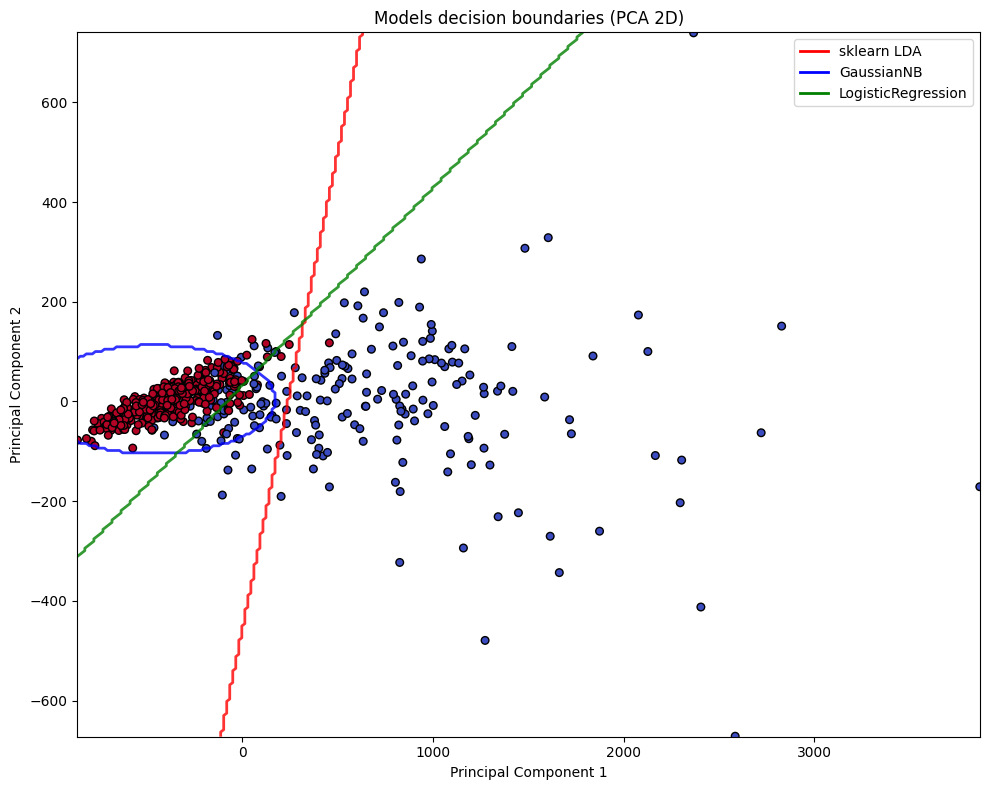

In [34]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import numpy as np
from matplotlib.lines import Line2D

# 1. 描画比較用に全モデルをまとめた辞書を用意（My LDAは除外）
models_for_plot = {
    "sklearn LDA": LinearDiscriminantAnalysis(),
    "GaussianNB": GaussianNB(),
    "LogisticRegression": LogisticRegression(max_iter=10000)
}

# 2. PCAで元のデータ(X)を2次元に圧縮
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 2次元になったデータで、再度「訓練・テスト」に分割
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.3, random_state=42
)

# 3. 全モデルの決定境界を同一図に重ねて描画
colors = ["red", "blue", "green"]
fig, ax = plt.subplots(figsize=(10, 8))

# 描画範囲のグリッドを作成
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

proxies = []
for (name, model), color in zip(models_for_plot.items(), colors):
    model.fit(X_train_pca, y_train_pca)
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)
    # 決定境界（クラスの切り替わり）を等高線で描画
    ax.contour(xx, yy, Z, levels=[0.5], colors=[color], linewidths=2, alpha=0.8)
    proxies.append(Line2D([0], [0], color=color, lw=2, label=name))

# 元データ点を重ねてプロット（クラスで色分け）
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolor='k', s=30)

ax.set_title("Models decision boundaries (PCA 2D)")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend(handles=proxies, loc="upper right")
plt.tight_layout()
plt.show()

## 全体の考察

### 結果のまとめ

- **Accuracy 比較**: 出力の表から、「My LDA」と「sklearn LDA」の精度が **0.9532** で完全に一致してた。実装が正しかったようだ。LDAがGaussianNBを上回っている。どちらも正規分布を仮定する生成型モデルだが、このデータセットの特徴量間に無視できない相関があり、それを考慮したLDAがより適切な境界を引けている。LogisticRegressionが最高精度を記録した。ロジスティック回帰は分布を仮定せず、境界そのものを直接最適化するため、外れ値やひずみにも対応できていると言える。
- **決定境界の特徴**: LDAとLogisticRegressionの決定境界は直線であるが、前者は共通の共分散行列を仮定して直線を引いているのに対し、後者は分布の仮定に縛られず、2つの集団を最も効率的に分ける角度で直線を引いている。GaussianNBは他二つと違い、楕円状の境界で、密集した赤クラスを包み込むような形になっている。これはLDAにおいて、全クラスで共通の分散を強制することで二次の項を相殺しているのに対し、GaussianNBではクラスごとに個別の分散を許容し、PC1とPC2を無相間としているため、軸に平行な二次曲線になっていると考えられる。


## AI利用について

本演習課題の実施にあたり、以下の通りAIを活用した。

* 関数の調査・学習
    * 実現したい処理を行える関数の選定から、必要な引数、内部の処理内容、返り値についてAIに質問し、理解を深めた上で実装と確認を行った。
    * 調査した主な関数・メソッド: `load_breast_cancer`, `train_test_split`, `accuracy_score`, `confusion_matrix`

* グラフのプロット（Copilotの活用）
    * 次元削減後のデータの散布図と決定境界を可視化するためのコード作成にCopilotを活用した。
    * 生成されたコードと出力されたグラフは自分で内容の確認と検証を行った。

* マークダウンの書き方
    * マークダウンでの数式、箇条書きのやり方を聞いた。